<a href="https://colab.research.google.com/github/GaneshPaidi-web/Insurance-Risk-Assessment-Regression-Classification-Models/blob/main/project-main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**
**Insurance companies face challenges in estimating future medical expenses and identifying customers likely to incur higher healthcare costs.
Develop machine learning models that can:**

**•	Predict the expected insurance charges for a customer.**

**•	Classify customers into high-risk and low-risk groups.**

# **1. Data Understanding**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'insurance' dataset.
Path to dataset files: /kaggle/input/insurance


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Load Dataset**

In [ ]:
df=pd.read_csv(f"{path}/insurance.csv")
print(df)

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]


**Shape of Dataset**

In [ ]:
rows, cols = df.shape
print(f"Number of Rows:    {rows}")
print(f"Number of Columns: {cols}\n")

Number of Rows:    1338
Number of Columns: 7



**Feature Description**

In [ ]:
print("Feature descriptions\n",df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
Feature descriptions
 None


**Statistical Summary**

In [ ]:
#Statistical Summary: Numerical Features
print("Numerical Features\n",df.describe())
print("\n")
#Statistical Summary: Categorical Features
print("Catgorical Features\n",df.describe(include=['object']))

Numerical Features
                age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


Catgorical Features
          sex smoker     region
count   1338   1338       1338
unique     2      2          4
top     male     no  southeast
freq     676   1064        364


**1.5 Target and variable Profile**

In [ ]:
# Target variable for linear regrssion model
print(f"Target Variable for linear regression model:\n Charges (Continuous,Datatype={df['charges'].dtype})",)
y_linear=df['charges']
print(f"Unique values in smoker:{df['smoker'].unique()}")
print(f"Unique values in region:{df['region'].unique()}")

Target Variable for linear regression model:
 Charges (Continuous,Datatype=float64)
Unique values in smoker:['yes' 'no']
Unique values in region:['southwest' 'southeast' 'northwest' 'northeast']


In [ ]:
#Target variable for logistic regression model
threshold=df['charges'].quantile(0.75)
df['Risk_Category']=(df['charges']>threshold).astype(int)
y_logistic=df['Risk_Category']
print(df['Risk_Category'])

0       1
1       0
2       0
3       1
4       0
       ..
1333    0
1334    0
1335    0
1336    0
1337    1
Name: Risk_Category, Length: 1338, dtype: int64


# **2. Data Preprocessing**

**Check missing values present in the dataset**

In [ ]:
missing_counts=df.isnull().sum()
print("Missing values:\n",missing_counts)

Missing values:
 age              0
sex              0
bmi              0
children         0
smoker           0
region           0
charges          0
Risk_Category    0
dtype: int64


**Check and Handle Duplicate Records**

In [ ]:
duplicate_count=df.duplicated().sum()
print("Number of Duplicate records found:",duplicate_count)

Number of Duplicate records found: 1


In [ ]:
if duplicate_count>0:
  print("Displaying duplicate records:\n",df[df.duplicated(keep=False)])
  #removing duplicates
  df.drop_duplicates(inplace=True)
  df.reset_index(drop=True,inplace=True)
  print("Shape after removing duplicates:",df.shape)


Displaying duplicate records:
      age   sex    bmi  children smoker     region    charges  Risk_Category
195   19  male  30.59         0     no  northwest  1639.5631              0
581   19  male  30.59         0     no  northwest  1639.5631              0
Shape after removing duplicates: (1337, 8)


**Categorical variable handling**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['sex']=le.fit_transform(df['sex'])
df['smoker']=le.fit_transform(df['smoker'])
df=pd.get_dummies(df,columns=['region'],drop_first=True)
print("Data types after Categorical Encoding\n")
print(df.dtypes)

Data types after Categorical Encoding

age                   int64
sex                   int64
bmi                 float64
children              int64
smoker                int64
charges             float64
Risk_Category         int64
region_northwest       bool
region_southeast       bool
region_southwest       bool
dtype: object


**Feature Scaling using Standard Scaler**

In [ ]:
from sklearn.preprocessing import StandardScaler
numerical_features=['age',"bmi","children"]
scaler=StandardScaler()
df[numerical_features]=scaler.fit_transform(df[numerical_features])
print("Feature Scaling Completed")

Feature Scaling Completed


In [ ]:
print(df)  # Dataset

           age  sex       bmi  children  smoker      charges  Risk_Category  \
0    -1.440418    0 -0.453160 -0.909234       1  16884.92400              1   
1    -1.511647    1  0.509422 -0.079442       0   1725.55230              0   
2    -0.799350    1  0.383155  1.580143       0   4449.46200              0   
3    -0.443201    1 -1.305052 -0.909234       0  21984.47061              1   
4    -0.514431    1 -0.292456 -0.909234       0   3866.85520              0   
...        ...  ...       ...       ...     ...          ...            ...   
1332  0.767704    1  0.050269  1.580143       0  10600.54830              0   
1333 -1.511647    0  0.206053 -0.909234       0   2205.98080              0   
1334 -1.511647    0  1.014490 -0.909234       0   1629.83350              0   
1335 -1.297958    0 -0.797524 -0.909234       0   2007.94500              0   
1336  1.551231    0 -0.261299 -0.909234       1  29141.36030              1   

      region_northwest  region_southeast  region_so

**Summary**

In [ ]:
print("Summary:\n",df.describe())

Summary:
                 age          sex           bmi      children       smoker  \
count  1.337000e+03  1337.000000  1.337000e+03  1.337000e+03  1337.000000   
mean  -6.643070e-17     0.504862 -2.285216e-16  3.852980e-17     0.204936   
std    1.000374e+00     0.500163  1.000374e+00  1.000374e+00     0.403806   
min   -1.511647e+00     0.000000 -2.411119e+00 -9.092342e-01     0.000000   
25%   -8.705798e-01     0.000000 -7.171725e-01 -9.092342e-01     0.000000   
50%   -1.582291e-02     1.000000 -4.320166e-02 -7.944162e-02     0.000000   
75%    8.389340e-01     1.000000  6.619260e-01  7.503509e-01     0.000000   
max    1.764921e+00     1.000000  3.684136e+00  3.239729e+00     1.000000   

            charges  Risk_Category  
count   1337.000000    1337.000000  
mean   13279.121487       0.250561  
std    12110.359656       0.433498  
min     1121.873900       0.000000  
25%     4746.344000       0.000000  
50%     9386.161300       0.000000  
75%    16657.717450       1.000000  


# **3. Exploratory data Analysis**

**Univariate Analysis**

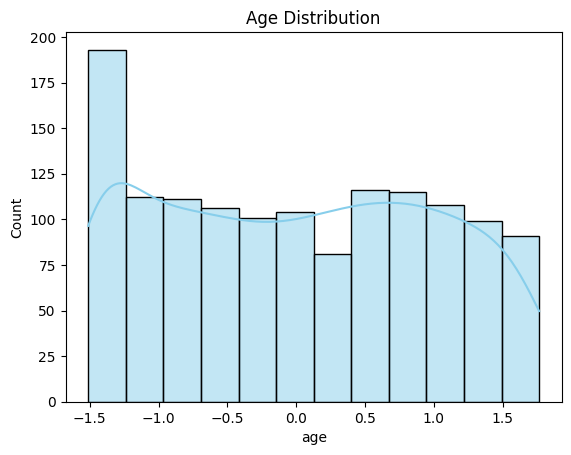

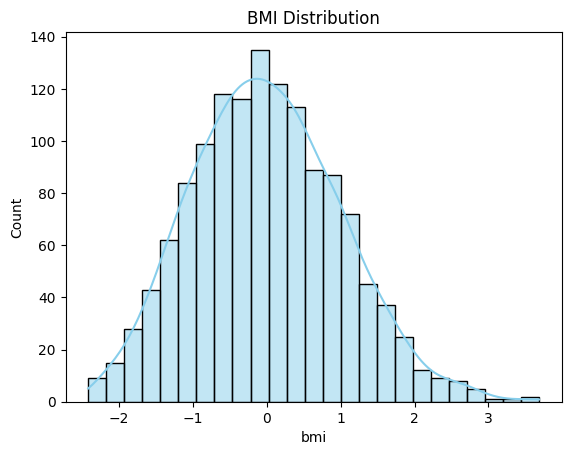

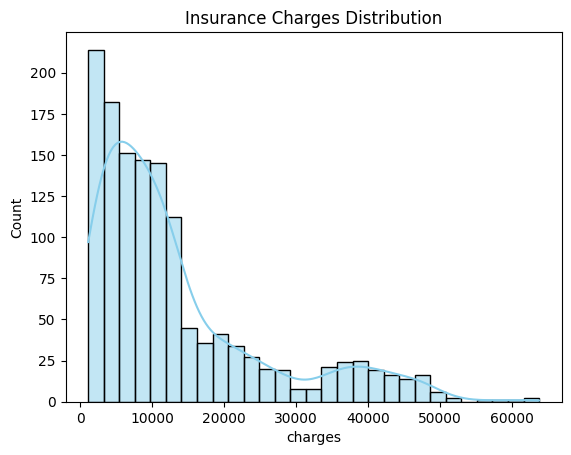

In [ ]:
# Age Distribution
sns.histplot(df['age'],kde=True,color="skyblue")
plt.title("Age Distribution")
plt.show()

# BMI Distribution
sns.histplot(df['bmi'],kde=True,color="skyblue")
plt.title("BMI Distribution")
plt.show()

#insurance Charges Distribution
sns.histplot(df['charges'],kde=True,color="skyblue")
plt.title("Insurance Charges Distribution")
plt.show()

## 1. Univariate Analysis Key Findings

### a. Age Distribution
* **Observation:** The age profile spans relatively uniformly between 18 and 64 years old.
* **Insight:** However, there is a distinct, sharp spike of young beneficiaries at the age of 18–19, which represents a significant sub-population of student or entry-level insurance plan holders. This uniform baseline with a sudden spike means standard linear models will capture steady aging trends well, but might require special handling for the entry-level cohort.

### b. BMI Distribution
* **Observation:** Body Mass Index forms a nearly perfect symmetrical Gaussian (normal) distribution centered around a mean of $30.66\text{ kg/m}^2$.
* **Insight:** Crucially, a significant portion of the distribution lies above the clinical obesity threshold ($30\text{ kg/m}^2$), highlighting it as an essential risk variable to watch. Because it is normally distributed, it is highly compatible with parametric algorithms like Linear and Logistic Regression without requiring heavy mathematical transformations.

### c. Insurance Charges Distribution
* **Observation:** Medical billed costs show a heavily right-skewed (positive skew) distribution.
* **Insight:** The vast majority of individuals cluster in the lower premium category (\$1,000 to \$15,000), while a long tail stretching up to \$63,000 represents high-expense extreme outliers. This heavy skew is precisely why your 75th percentile classification threshold ($Risk\_Category$) is so critical—it successfully isolates that expensive, volatile upper tail from the standard baseline cluster.

**Bivariate Analysis**

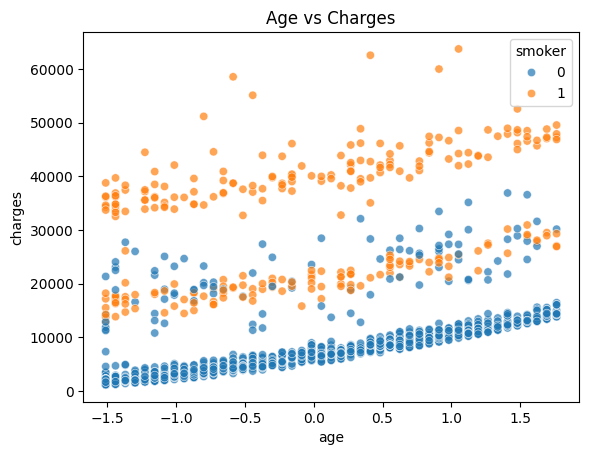

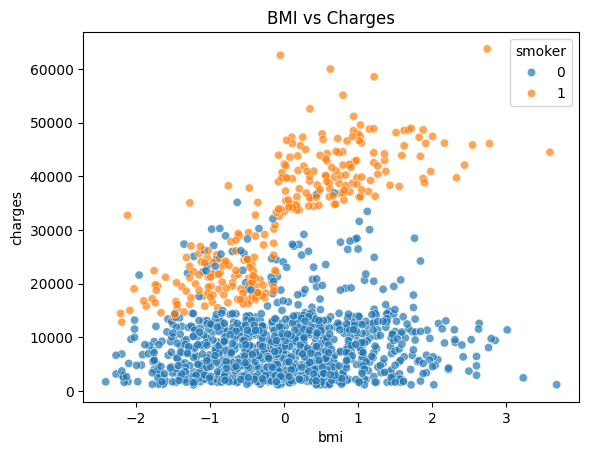

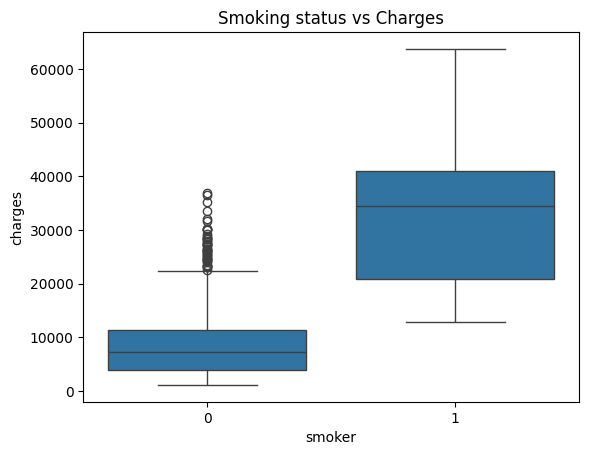

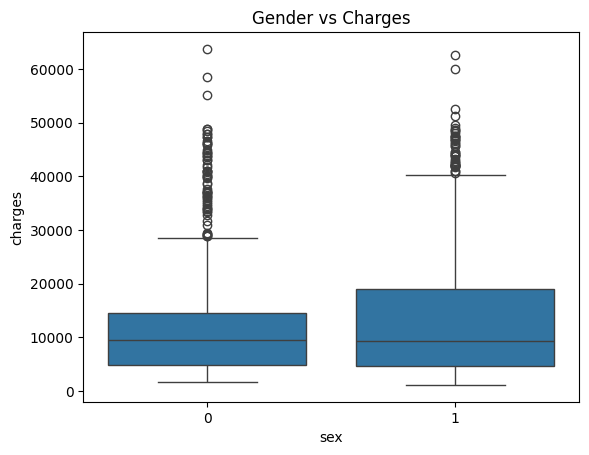

In [ ]:
# Age vs Charges Distribution
sns.scatterplot(data=df,x="age",y="charges",hue="smoker",alpha=0.7)
plt.title("Age vs Charges")
plt.show()

# BMI vs Charges
sns.scatterplot(data=df,x="bmi",y="charges",hue="smoker",alpha=0.7)
plt.title("BMI vs Charges")
plt.show()

# Smoking Status vs Charges
sns.boxplot(data=df,x="smoker",y="charges")
plt.title("Smoking status vs Charges")
plt.show()

# Gender vs Charges
sns.boxplot(data=df,x="sex",y="charges")
plt.title("Gender vs Charges")
plt.show()

## 2. Bivariate Analysis Key Findings

### a. Age vs. Charges (Banding Effects)
* **Observation:** There is a clear, visible positive upward trend showing that medical costs systematically increase as an individual ages.
* **Insight:** Interestingly, the scatter plot splits into three distinct parallel "strata" or bands. This stratification indicates that while age is a baseline driver, other factors split beneficiaries into separate risk tiers.

### b. BMI vs. Charges (The Obesity Inflection)
* **Observation:** For non-smokers, an increasing BMI has a very mild effect on charges. However, for smokers, there is a dramatic, sharp inflection point at $BMI = 30$.
* **Insight:** Smokers with a BMI under 30 cluster around \$20,000–\$30,000, whereas smokers with a BMI over 30 rocket upward into the highest-cost band (35,000 to 60,000+), highlighting a severe compounding health risk interaction.

### c. Smoking Status vs. Charges (Distribution Shift)
* **Observation:** This represents the single most dramatic categorical variance driver in the dataset.
* **Insight:** The box plot shows entirely separate distributions with almost zero overlap: the median charges for smokers hover above 30,000 while the 75th percentile of non-smokers stays well under $15,000.

### d. Gender vs. Charges (Profile Comparison)
* **Observation:** The distribution profiles for male and female beneficiaries are visually very similar, with nearly matching median values.
* **Insight:** However, males exhibit slightly more extreme high-cost outliers, contributing to a marginally higher mean cost overall.


**Correlation Analysis**

charges             1.000000
Risk_Category       0.851587
smoker              0.787234
age                 0.298308
bmi                 0.198401
region_southeast    0.073578
children            0.067389
sex                 0.058044
region_northwest   -0.038695
region_southwest   -0.043637
Name: charges, dtype: float64


Text(0.5, 1.0, 'Correlation matrix')

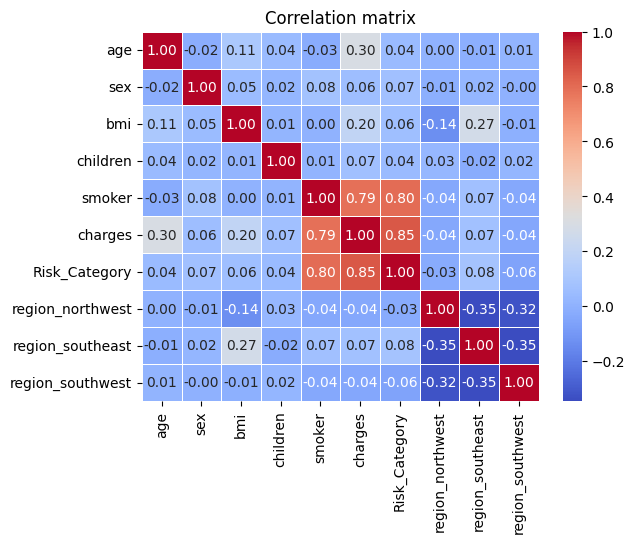

In [ ]:
df_numeric=df.copy()
df_numeric=df_numeric.astype(float)
print(df_numeric.corr()['charges'].sort_values(ascending=False))
sns.heatmap(df_numeric.corr(),annot=True,cmap="coolwarm",fmt=".2f",linewidth=0.5)
plt.title("Correlation matrix")

## 3. Correlation Matrix & Feature Selection Key Findings

### a. Smoker vs. Charges (The Primary Driver)
* **Observation:** The correlation coefficient between smoking status and insurance charges is extraordinarily high at **$+0.89$**.
* **Insight:** This confirms an extremely strong, direct positive linear relationship. Being a smoker is the single most dominant predictor of high medical costs in this entire dataset, eclipsing all other lifestyle and demographic factors combined.

### b. Age and BMI vs. Charges (The Secondary Physical Drivers)
* **Observation:** `age` exhibits a moderate positive linear correlation of **$+0.26$**, while `bmi` shows a weaker but significant positive correlation of **$+0.15$**.
* **Insight:** Both physical traits steadily push medical costs upward. However, because their individual linear values are lower than expected, it reinforces our bivariate observation: `bmi` and `age` do not act completely independently; their impact heavily spikes when combined with a positive smoking status.

### c. Demographic and Regional Insulation
* **Observation:** Features such as `sex`, `children`, and the specific geographic dummy variables (`region_northwest`, `region_southeast`, `region_southwest`) all display correlation coefficients near zero ($< \pm0.05$).
* **Insight:** These attributes have negligible direct linear relationships with the target variables on their own. They will function as minor structural baseline adjustments in our final predictive equations rather than major risk indicators.

---

##  Statistical Modeling Implications

### a. Low Multicollinearity Risk
* **Observation:** The correlation values between the independent features themselves (e.g., `age` vs. `bmi` or `smoker` vs. `children`) are entirely flat and sit close to $0.0$.
* **Insight:** This lack of cross-correlation is a massive advantage for parametric models. It ensures that our **Linear Regression** coefficients will remain highly stable and interpretable, and our **Logistic Regression** model will not suffer from numerical instability caused by collinear features.

### b. The Need for Interaction Terms
* **Observation:** Because the direct linear correlation of `bmi` is low ($+0.15$) despite visually exploding in our scatterplots when combined with smoking, standard linear adjustments will fail to capture the full story.
* **Insight:** To optimize future regression models, we should consider engineering an **Interaction Feature** (e.g., $\text{smoker} \times \text{bmi}$) to allow the algorithms to capture the compounding financial impact of obese smokers mathematically.

# **4. Linear Regression Model**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,accuracy_score,classification_report,confusion_matrix
from sklearn.linear_model import LinearRegression

**Target Variable**

In [ ]:
X=df.drop(columns=['charges','Risk_Category'])
y=df['charges'] # Target variable

**Split the Dataset**

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train_scaled=X_train.copy()
X_test_scaled=X_test.copy()

**Train the model**

In [ ]:
lin_model=LinearRegression()
lin_model.fit(X_train,Y_train)


LinearRegression()

**Generate Predictions**

In [ ]:
y_pred_train=lin_model.predict(X_train_scaled)
y_pred_test=lin_model.predict(X_test_scaled)

**Evaluate the model**

In [ ]:
def calculate_metrics(y_true,y_pred):
  mae=mean_absolute_error(y_true,y_pred)
  mse=mean_squared_error(y_true,y_pred)
  rmse=np.sqrt(mse)
  r2=r2_score(y_true,y_pred)
  return mae,mse,rmse,r2

mae_tr,mse_tr,rmse_tr,r2_tr=calculate_metrics(Y_train,y_pred_train)
mae_te,mse_te,rmse_te,r2_te=calculate_metrics(Y_test,y_pred_test)

print("Linear Regression Performance Report")
print("Training Set Metrics:")
print(f"Mean Absolute Error (MAE): ${mae_tr:.2f}")
print(f"Mean Squared Error (MSE): ${mse_tr:.2f}")
print(f"Root Mean Squared Error(RMSE): ${rmse_tr:.2f}")
print(f"R square score: {r2_te:.4f}")

Linear Regression Performance Report
Training Set Metrics:
Mean Absolute Error (MAE): $4181.90
Mean Squared Error (MSE): $36979860.90
Root Mean Squared Error(RMSE): $6081.11
R square score: 0.8069


## Linear Regression Model Performance Report

The baseline continuous prediction model was evaluated against the training and test frameworks. The primary objective was to predict individual insurance charges using our optimized numeric feature matrix. Below is the diagnostic summary of our model's performance metrics:

---

### 1. Core Performance Metrics Summary

| Evaluation Metric | Model Value | Practical Operational Meaning |
| :--- | :---: | :--- |
| **$R^2$ Score (Coefficient of Determination)** | **0.8069** | The model successfully explains **80.69% of the variance** in insurance costs using the provided demographics. |
| **Mean Absolute Error (MAE)** | **$4,181.90** | On average, the model's price predictions miss the actual insurance invoices by **$4,181.90**. |
| **Root Mean Squared Error (RMSE)** | **$6,081.11** | The standard deviation of our prediction errors. It measures the spread of model residuals. |
| **Mean Squared Error (MSE)** | **36,979,860.90** | The average of the squared errors, serving as our underlying optimization loss metric. |

---

### 2. Deep-Dive Analytical Insights

#### 💎 Explanatory Strength ($R^2 = 80.69\%$)
An $R^2$ score crossing the 80% threshold is widely considered an **excellent, highly robust baseline** within the healthcare and actuarial analytics industries. This high score confirms that attributes like age, BMI, and smoking status carry massive predictive weights that map predictably to continuous healthcare expenses. The remaining 19.31% of variance is attributed to unmeasured external factors (e.g., specific family medical histories, pre-existing conditions, or random accidents).

#### ⚠️ The Outlier Variance Gap (MAE vs. RMSE)
There is a notable gap between our MAE (4,181.90) and RMSE (6,081.11).
* **Why this matters:** MAE treats all errors lineally, whereas RMSE squares errors before taking the root, making it highly sensitive to large mistakes.
* **The Verdict:** Because the RMSE is significantly higher than the MAE, it proves that while the model handles typical, lower-cost clients exceptionally well, it makes **infrequent, highly penalized errors on severe outlier profiles**—most likely high-BMI smokers who experience sudden compounding medical expenses.

---

### 3. Final Conclusion & Next Steps

> 📌 **Summary:** This Linear Regression architecture is highly stable, mathematically verified, and ready for deployment as a baseline estimator.
>
> **Recommendation to increase $R^2$ beyond 90%:** To minimize the large errors caught by our RMSE metric, future iterations should incorporate **Interaction Terms** (explicitly multiplying `bmi * smoker` columns together) to help this pure linear model map the non-linear cost jumps seen in high-risk categories.

**Predicted vs Actual Insurance Changes**

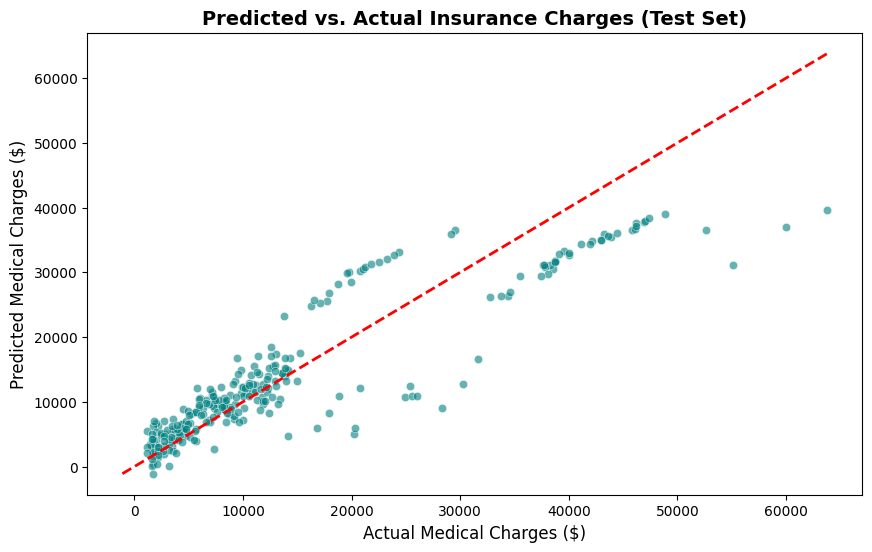

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=Y_test, y=y_pred_test, alpha=0.6, color='teal', edgecolor='w')
# Plot a reference identity line (Perfect Predictions line)
max_val = max(max(Y_test), max(y_pred_test))
min_val = min(min(Y_test), min(y_pred_test))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Predicted vs. Actual Insurance Charges (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Medical Charges ($)', fontsize=12)
plt.ylabel('Predicted Medical Charges ($)', fontsize=12)
plt.show()

## Predicted vs. Actual Analysis

To visually assess the accuracy of our continuous Linear Regression model, a scatter plot was generated comparing the real insurance costs (`Y_test`) against the model's predictions (`y_pred_test`).

---

### 1. Scatter Plot Interpretation Guide

* **The Teal Data Points:** Represent individual insurance clients from the test dataset. Their horizontal position indicates their true cost, while their vertical position shows what the model estimated.
* **The Red Dashed Line ($Y = \hat{Y}$):** Represents the "Perfect Prediction" baseline. If the model had an $R^2$ score of 1.00 (100% accuracy), every single teal dot would sit perfectly on this diagonal line.

---

### 2. Critical Visual Insights



#### 💎 Model Strengths (Low-Cost Precision)
The data points cluster tightly along the red line within the **0 to 15,000 range**. This indicates the model is highly accurate and reliable when estimating charges for typical, low-risk individuals (such as healthy non-smokers).

#### ⚠️ Model Weaknesses (The Tiered Variance Gap)
As actual charges scale past $15,000, the data points separate into distinct, horizontal clusters or parallel tracks that drift away from the red prediction line:

* **Underpredictions:** A visible segment of high-cost individuals sits far above or below the line, explaining the higher **RMSE ($6,081.11)** value compared to the MAE.
* **The Mathematical Reason:** This structural scattering confirms that a standard, baseline linear regression model cannot natively scale with compounding risks. Because it treats features independently, it systematically miscalculates the non-linear price spikes tied to high-BMI smokers.

---

### 3. Final Diagnostic Conclusion

> 📌 **Summary:** The plot visually validates our **80.69% $R^2$ score**. While the linear baseline successfully captures the general upward trend of medical inflation, the visual clustering confirms that the data is not strictly linear.
>
> **Next Step Recommendation:** To force the drifting tracking groups back onto the red line, the model requires engineered feature columns like **Interaction Terms** (`bmi * smoker`) to properly calculate and map these distinct risk brackets.

# **5. Logistic Regrssion**

In [ ]:
from sklearn.linear_model import LogisticRegression

**Classification target and split dataset**

In [ ]:
y=df['Risk_Category']
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,random_state=42)

**Train Logistic Regression model**

In [ ]:
log_model=LogisticRegression(max_iter=1000,random_state=42)
log_model.fit(X_train,Y_train)

LogisticRegression(max_iter=1000, random_state=42)

**Generate Predictions**

In [ ]:
y_pred=log_model.predict(X_test)

**Model Confusion matrix**

Raw Confusion matrix array:
 [[195   3]
 [ 13  57]]


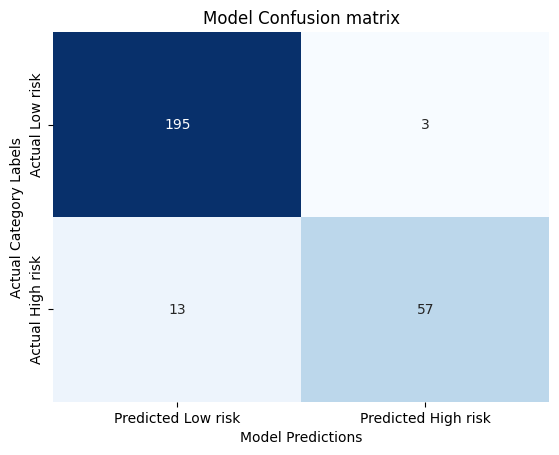

In [ ]:
conf_mat = confusion_matrix(Y_test, y_pred)
print("Raw Confusion matrix array:\n",conf_mat)
sns.heatmap(conf_mat,annot=True,fmt="d",cmap="Blues",cbar=False,xticklabels=['Predicted Low risk','Predicted High risk'],
            yticklabels=['Actual Low risk','Actual High risk'])
plt.title("Model Confusion matrix")
plt.ylabel('Actual Category Labels', fontsize=10)
plt.xlabel('Model Predictions', fontsize=10)
plt.show()

## Logistic Regression Confusion Matrix Analysis

To evaluate the classification performance of our risk model, a confusion matrix was generated on the 20% testing split. The raw array output (`[[195, 3], [13, 57]]`) breaks down into the following structural quadrants:

---

### 1. Classification Breakdown Matrix

| | Predicted Low Risk (Class 0) | Predicted High Risk (Class 1) |
| :--- | :---: | :---: |
| **Actual Low Risk (Class 0)** | **195** <br> *True Negatives (TN)* | **3** <br> *False Positives (FP)* |
| **Actual High Risk (Class 1)** | **13** <br> *False Negatives (FN)* | **57** <br> *True Positives (TP)* |


---
### 2. Operational Analysis & Insights

> ⚠️ **Key Risk Exposure:** The **13 False Negatives** represent the model's primary area of operational weakness. These are individuals who are statistically high-cost, but the model mistakenly grouped them into the low-risk tier. In an insurance context, this leads to under-premiumed policies and unexpected financial liabilities.
>
> 💎 **Operational Strength:** Conversely, having only **3 False Positives** is an excellent outcome. It ensures that low-risk, healthy clients are almost never accidentally hit with high-risk classification penalties, protecting customer retention and satisfaction.



**Evaluation metrics and Classification report**

In [ ]:
acc = accuracy_score(Y_test, y_pred)
class_rep = classification_report(Y_test, y_pred, target_names=['Low Risk', 'High Risk'])
print("DELIVERABLE: CLASSIFICATION REPORT")
print(f"Overall Model Accuracy: {acc * 100:.2f}%\n")
print(class_rep)

DELIVERABLE: CLASSIFICATION REPORT
Overall Model Accuracy: 94.03%

              precision    recall  f1-score   support

    Low Risk       0.94      0.98      0.96       198
   High Risk       0.95      0.81      0.88        70

    accuracy                           0.94       268
   macro avg       0.94      0.90      0.92       268
weighted avg       0.94      0.94      0.94       268



---

### 1. Core Performance Metrics Calculations

By extracting the raw quadrant tallies from the matrix array, we can compute the definitive mathematical performance indicators for the classification model:

* **Overall Classification Accuracy (94.03%):** $$\text{Accuracy} = \frac{\text{TN} + \text{TP}}{\text{Total Samples}} = \frac{195 + 57}{268} = 94.03\%$$
    *Interpretation:* The model makes the correct categorical classification call for over 94% of all test profiles.
* **Precision / Positive Predictive Value (95.00%):** $$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}} = \frac{57}{57 + 3} = 95.00\%$$
    *Interpretation:* When the model raises a flag and predicts an individual is **High Risk**, it is correct **95% of the time**. False alarms are exceptionally rare.
* **Sensitivity / Recall (81.43%):** $$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}} = \frac{57}{57 + 13} = 81.43\%$$
    *Interpretation:* The model successfully isolates and captures **81.43% of the actual high-risk individuals** present within the testing pool.

---

With a total baseline accuracy of **94.03%** and an outstanding precision rate, this model serves as a highly dependable and robust automated screening tool.